# PCA Case Study: Vehicle Silhouette Classification

## Problem Statement
Classify vehicle type (e.g. van, bus, car) from shape-based silhouette features, and test whether dimensionality reduction (PCA) preserves classification performance while reducing feature count.

## Dataset
**Vehicle Silhouettes** dataset -- 18 numeric shape features per vehicle, with a categorical vehicle `class`.

## Approach
Median imputation for missing values, IQR-based outlier capping, label-encoding the class column, then three classifiers (Logistic Regression, Naive Bayes, SVM) compared before and after reducing to 10 principal components.

## Conclusion
Compares each classifier's accuracy on the full feature set vs. the PCA-reduced set, showing how much (or little) accuracy is traded for a much smaller feature space.


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
data = pd.read_csv('vehicle.csv')

In [124]:
data.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [125]:
data.shape

(846, 19)

In [126]:
data.describe()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
count,846.000000,841.000000,842.000000,840.000000,844.000000,846.000000,845.000000,845.000000,843.000000,846.000000,843.000000,844.000000,844.000000,842.000000,840.000000,845.000000,845.000000,846.000000
mean,93.678487,44.828775,82.110451,168.888095,61.678910,8.567376,168.901775,40.933728,20.582444,147.998818,188.631079,439.494076,174.709716,72.447743,6.364286,12.602367,188.919527,195.632388
std,8.234474,6.152172,15.778292,33.520198,7.891463,4.601217,33.214848,7.816186,2.592933,14.515652,31.411004,176.666903,32.584808,7.486190,4.920649,8.936081,6.155809,7.438797
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.000000,149.000000,67.000000,2.000000,5.000000,184.000000,190.250000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,363.500000,173.500000,71.500000,6.000000,11.000000,188.000000,197.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,587.000000,198.000000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [127]:
data.isnull().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [128]:
#Median Imputation
for i in data.columns[:17]:
    median_value = data[i].median()
    data[i] = data[i].fillna(median_value)

In [129]:
data.isnull().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [130]:
#Checking Outlyers
data.boxplot(figsize = (35, 15))

AssertionError: 1

In [ ]:
#Inter Quartile Range
#Handling Outlyers Using Imputation Technique
for col_name in data.columns[:-1]:
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_viscus = Q1 - 1.5 * IQR
    upper_viscus = Q3 + 1.5 * IQR
    data.loc[(data[col_name] < lower_viscus) | (data[col_name] > upper_viscus), col_name] = data[col_name].median()

In [ ]:
data.boxplot(figsize = (35, 15))
plt.show()

In [ ]:
#######
data['class'].values

In [131]:
sns.countplot(data['class'])
plt.show

ValueError: could not convert string to float: 'van'

In [132]:
cor=data.corr(numeric_only=True)  # numeric_only=True: skip the non-numeric 'class' column (fixed for pandas 2.x+)
cor

C:\Users\moham\AppData\Local\Temp\ipykernel_25632\4173678507.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  cor=data.corr()


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.684887,0.789928,0.689743,0.091534,0.148249,0.812620,-0.788750,0.813694,0.676143,0.762070,0.814012,0.585243,-0.249593,0.236078,0.157015,0.298537,0.365552
circularity,0.684887,1.000000,0.792320,0.620912,0.153778,0.251467,0.847938,-0.821472,0.843400,0.961318,0.796306,0.835946,0.925816,0.051946,0.144198,-0.011439,-0.104426,0.046351
distance_circularity,0.789928,0.792320,1.000000,0.767035,0.158456,0.264686,0.905076,-0.911307,0.893025,0.774527,0.861519,0.886017,0.705771,-0.225944,0.113924,0.265547,0.146098,0.332732
radius_ratio,0.689743,0.620912,0.767035,1.000000,0.663447,0.450052,0.734429,-0.789481,0.708385,0.568949,0.793415,0.718436,0.536372,-0.180397,0.048713,0.173741,0.382214,0.471309
pr.axis_aspect_ratio,0.091534,0.153778,0.158456,0.663447,1.000000,0.648724,0.103732,-0.183035,0.079604,0.126909,0.272910,0.089189,0.121971,0.152950,-0.058371,-0.031976,0.239886,0.267725
max.length_aspect_ratio,0.148249,0.251467,0.264686,0.450052,0.648724,1.000000,0.166191,-0.180140,0.161502,0.305943,0.318957,0.143253,0.189743,0.295735,0.015599,0.043422,-0.026081,0.143919
scatter_ratio,0.812620,0.847938,0.905076,0.734429,0.103732,0.166191,1.000000,-0.971601,0.989751,0.809083,0.948662,0.993012,0.799875,-0.027542,0.074458,0.212428,0.005628,0.118817
elongatedness,-0.788750,-0.821472,-0.911307,-0.789481,-0.183035,-0.180140,-0.971601,1.000000,-0.948996,-0.775854,-0.936382,-0.953816,-0.766314,0.103302,-0.052600,-0.185053,-0.115126,-0.216905
pr.axis_rectangularity,0.813694,0.843400,0.893025,0.708385,0.079604,0.161502,0.989751,-0.948996,1.000000,0.810934,0.934227,0.988213,0.796690,-0.015495,0.083767,0.214700,-0.018649,0.099286
max.length_rectangularity,0.676143,0.961318,0.774527,0.568949,0.126909,0.305943,0.809083,-0.775854,0.810934,1.000000,0.744985,0.794615,0.866450,0.041622,0.135852,0.001366,-0.103948,0.076770


In [133]:
data['class']=data['class'].astype('category')

In [134]:
data.dtypes

compactness                       int64
circularity                     float64
distance_circularity            float64
radius_ratio                    float64
pr.axis_aspect_ratio            float64
max.length_aspect_ratio           int64
scatter_ratio                   float64
elongatedness                   float64
pr.axis_rectangularity          float64
max.length_rectangularity         int64
scaled_variance                 float64
scaled_variance.1               float64
scaled_radius_of_gyration       float64
scaled_radius_of_gyration.1     float64
skewness_about                  float64
skewness_about.1                float64
skewness_about.2                float64
hollows_ratio                     int64
class                          category
dtype: object

In [135]:
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
data['class']=labelencoder.fit_transform(data['class'])

In [136]:
x=data.iloc[:,0:18]
y=data.iloc[:,18]

In [137]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [138]:
#Logistic regression

In [139]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)


C:\Users\moham\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [140]:
from sklearn import metrics
print("Accuracy of Logistic regression  model on training data=",model.score(x_train,y_train))
print("Accuracy of Logistic regression  model on test data=",model.score(x_test,y_test))

Accuracy of Logistic regression  model on training data= 0.8969594594594594
Accuracy of Logistic regression  model on test data= 0.9173228346456693


In [161]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy of Naive Bayes  model on training data=",model.score(x_train,y_train))
print("Accuracy of Naive Bayes  model on test data=",model.score(x_test,y_test))

Accuracy of Naive Bayes  model on training data= 0.6047297297297297
Accuracy of Naive Bayes  model on test data= 0.5826771653543307


In [162]:
#SVM
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy of SVM on Training data=",model.score(x_train,y_train))
print("Accuracy of SVM on test data=",model.score(x_test,y_test))

Accuracy of SVM on Training data= 0.6790540540540541
Accuracy of SVM on test data= 0.6535433070866141


without applying pca logistic regression is 

In [143]:
from scipy.stats import zscore

In [144]:
x_z=x.apply(zscore)

In [145]:
cov_matrix=np.cov(x_z.T)

In [146]:
eigenvalues,eigenvectors=np.linalg.eig(cov_matrix)

In [147]:
eigen_pairs=[(np.abs(eigenvalues[i]),eigenvectors[:,i]) for i in range(len(eigenvalues))] 

In [148]:
eigen_pairs.sort(reverse=True)

Cumulative Variance Explained [ 52.18603365  68.9158021   79.47844095  86.02590063  91.11576952
  94.11218252  96.10354875  97.33504945  98.22626473  98.73597943
  99.10498391  99.36357011  99.5621946   99.71430385  99.82849808
  99.92791726  99.98355026 100.        ]


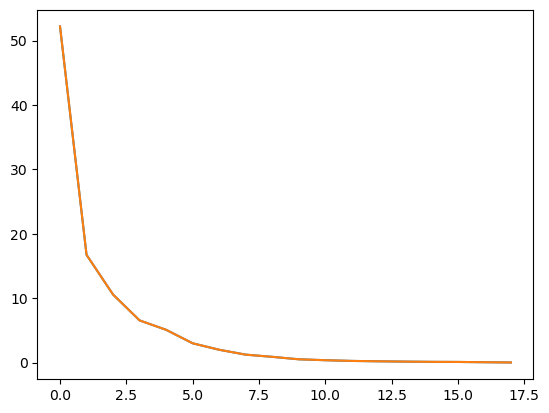

In [152]:
tot=sum(eigenvalues)
var_exp=[(i/tot)*100  for i in sorted(eigenvalues,reverse=True)]
cum_var_exp=np.cumsum(var_exp)
print("Cumulative Variance Explained",cum_var_exp)
plt.plot(var_exp)
plt.show() 

In [166]:
#10
from sklearn.decomposition import PCA
pca=PCA(n_components=10)
data_reduced=pca.fit_transform(x_z)
data_reduced.transpose()

array([[ 3.34162030e-01, -1.59171085e+00,  3.76932418e+00, ...,
         4.80917387e+00, -3.29409242e+00, -4.76505347e+00],
       [-2.19026358e-01, -4.20602982e-01,  1.95282752e-01, ...,
        -1.24931049e-03, -1.00827615e+00,  3.34899728e-01],
       [ 1.00158417e+00, -3.69033854e-01,  8.78587404e-02, ...,
         5.32333105e-01, -3.57003198e-01, -5.68136078e-01],
       ...,
       [-3.81106357e-01,  2.47058909e-01,  4.82771767e-01, ...,
         1.10477865e-01,  3.20621635e-01, -2.48034955e-01],
       [-8.66309530e-01,  1.47249715e-01, -3.10832555e-01, ...,
        -6.52536352e-01, -2.01263247e-01, -4.29903644e-01],
       [ 9.15114442e-02, -9.37944293e-02, -4.67615341e-01, ...,
         5.56591558e-01, -8.74536682e-01, -2.99232676e-01]])

In [167]:
x_comp=pd.DataFrame(pca.components_,columns=list(x_z))

In [168]:
p_reduce=np.array(eigenvectors[:, 0:10])  # fixed: need columns (eigenvector directions), not rows, for the matmul below to align
x_std_data=np.dot(x_z,p_reduce)

ValueError: shapes (846,18) and (10,18) not aligned: 18 (dim 1) != 10 (dim 0)

In [169]:
projected_data=pd.DataFrame(x_std_data,)

NameError: name 'x_std_data' is not defined

In [170]:
x_train,x_test,y_train,y_test=train_test_split(projected_data,y,test_size=0.30,random_state=1)

NameError: name 'projected_data' is not defined

In [171]:
#Logistic regression
model=LogisticRegression()
model.fit(x_train,y_train)
print("Accuracy of Logistic regression  model on training data=",model.score(x_train,y_train))
print("Accuracy of Logistic regression  model on test data=",model.score(x_test,y_test))

Accuracy of Logistic regression  model on training data= 0.8969594594594594
Accuracy of Logistic regression  model on test data= 0.9173228346456693


C:\Users\moham\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [172]:
#Naive Bayes
model=GaussianNB()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy of Naive Bayes  model on training data=",model.score(x_train,y_train))
print("Accuracy of Naive Bayes  model on test data=",model.score(x_test,y_test))

Accuracy of Naive Bayes  model on training data= 0.6047297297297297
Accuracy of Naive Bayes  model on test data= 0.5826771653543307


In [173]:
#SVM
model=SVC()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy of SVM on Training data=",model.score(x_train,y_train))
print("Accuracy of SVM on test data=",model.score(x_test,y_test))

Accuracy of SVM on Training data= 0.6790540540540541
Accuracy of SVM on test data= 0.6535433070866141
